### 1. Setup and Dataset Download
You need to upload your `kaggle.json` to the Colab environment first.

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import pywt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import lfilter
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix

# Insert your own Kaggle credentials before running
os.environ['KAGGLE_USERNAME'] = "YOUR_KAGGLE_USERNAME"
os.environ['KAGGLE_KEY'] = "YOUR_KAGGLE_API_KEY"

# Kaggle API setup
if not os.path.exists('/root/.kaggle/kaggle.json'):
    os.makedirs('/root/.kaggle', exist_ok=True)
    !echo '{"username":"'${KAGGLE_USERNAME}'","key":"'${KAGGLE_KEY}'"}' > /root/.kaggle/kaggle.json
    !chmod 600 /root/.kaggle/kaggle.json

if not os.path.exists('gtzan-dataset-music-genre-classification.zip'):
    !kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification
    !unzip -q gtzan-dataset-music-genre-classification.zip -d gtzan_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
100% 1.21G/1.21G [00:05<00:00, 227MB/s]



### 2. Feature Extraction Functions
Implementing the 30-dimensional feature vector exactly as specified in the paper.

In [2]:
def extract_timbral(y, sr):
    # 512 window, 23ms at 22050Hz
    n_fft = 512
    hop = 512

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop, roll_percent=0.85)[0]
    flux = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop)[0]

    # Low Energy: % of frames with RMS < mean RMS
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop)[0]
    low_energy = np.sum(rms < np.mean(rms)) / len(rms)

    # MFCC 1-5 (DC index 0 excluded)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=6, n_fft=n_fft, hop_length=hop)[1:6]

    features = [
        np.mean(centroid), np.var(centroid),
        np.mean(rolloff), np.var(rolloff),
        np.mean(flux), np.var(flux),
        np.mean(zcr), np.var(zcr),
        low_energy
    ]
    for m in mfcc:
        features.extend([np.mean(m), np.var(m)])

    return np.array(features)

def extract_rhythmic(y, sr):
    # DWT db4 6-level
    coeffs = pywt.wavedec(y, 'db4', level=6)
    processed_bands = []
    for c in coeffs[1:]: # Ignore approximation
        rect = np.abs(c)
        lpf = lfilter([1-0.99], [1, -0.99], rect)
        ds = lpf[::16] # Downsampling
        norm = ds - np.mean(ds)
        processed_bands.append(norm)

    # Sum bands and Autocorrelation
    min_len = min(len(b) for b in processed_bands)
    summed = np.sum([b[:min_len] for b in processed_bands], axis=0)
    corr = np.correlate(summed, summed, mode='full')[len(summed)-1:]

    # Peak picking (40-200 BPM)
    # sr_ds = sr / (original_hop * downsample_factor) is complex,
    # but we use standard indices for the rhythmic histogram peaks
    peaks = librosa.util.peak_pick(corr, pre_max=10, post_max=10, pre_avg=10, post_avg=10, delta=0.1, wait=10)
    peaks = peaks[peaks > 0]

    # Default values if peaks not found
    a0, a1, p1, p2 = 0.0, 0.0, 0.0, 0.0
    if len(peaks) > 0:
        sorted_peaks = peaks[np.argsort(corr[peaks])][::-1]
        a0 = corr[sorted_peaks[0]]
        p1 = float(sorted_peaks[0])
        if len(sorted_peaks) > 1:
            a1 = corr[sorted_peaks[1]]
            p2 = float(sorted_peaks[1])

    ra = a1/a0 if a0 > 0 else 0
    sum_hist = np.sum(corr)
    return np.array([a0, a1, ra, p1, p2, sum_hist])

def extract_pitch(y, sr):
    # YIN for f0
    f0 = librosa.yin(y, fmin=50, fmax=500, sr=sr)
    f0 = f0[~np.isnan(f0)]

    # Folded (Chroma) Histogram
    midi = librosa.hz_to_midi(f0)
    chroma = np.round(midi % 12).astype(int)
    fph = np.bincount(chroma, minlength=12)

    # Unfolded (MIDI) Histogram
    uph = np.bincount(np.round(midi).astype(int), minlength=128)

    fa0 = np.max(fph) if len(fph) > 0 else 0
    fp0 = np.argmax(fph) if len(fph) > 0 else 0
    up0 = np.argmax(uph) if len(uph) > 0 else 0

    peaks = np.argsort(fph)[::-1]
    ipo1 = abs(peaks[0] - peaks[1]) if len(peaks) > 1 else 0
    sum_pitch = np.sum(fph)

    return np.array([fa0, up0, fp0, ipo1, sum_pitch])

In [3]:
def process_dataset(root_dir):
    features, labels = [], []
    genres = os.listdir(root_dir)

    for genre in genres:
        genre_path = os.path.join(root_dir, genre)
        if not os.path.isdir(genre_path): continue

        print(f"Processing: {genre}")
        for file in tqdm(os.listdir(genre_path)):
            if file == 'jazz.00054.wav': continue
            try:
                path = os.path.join(genre_path, file)
                y, sr = librosa.load(path, sr=22050)

                f_t = extract_timbral(y, sr)
                f_r = extract_rhythmic(y, sr)
                f_p = extract_pitch(y, sr)

                feat = np.concatenate([f_t, f_r, f_p])
                if len(feat) == 30:
                    features.append(feat)
                    labels.append(genre)
            except Exception:
                continue

    return np.array(features), np.array(labels)

data_path = 'gtzan_data/Data/genres_original/'
if os.path.exists('X.npy') and os.path.exists('y.npy'):
    X = np.load('X.npy')
    y = np.load('y.npy', allow_pickle=True)
else:
    X, y = process_dataset(data_path)
    np.save('X.npy', X)
    np.save('y.npy', y)

Processing: disco


100%|██████████| 100/100 [00:52<00:00,  1.91it/s]


Processing: country


100%|██████████| 100/100 [00:31<00:00,  3.14it/s]


Processing: reggae


...

100%|██████████| 100/100 [00:32<00:00,  3.09it/s]


Processing: blues


100%|██████████| 100/100 [00:37<00:00,  2.66it/s]


Processing: jazz


100%|██████████| 100/100 [00:33<00:00,  2.96it/s]


### 3. Classification and Evaluation
Running k-NN and GMM Classifiers with 10-fold CV.

In [4]:
class GMMClassifier:
    def __init__(self, n_components):
        self.n_components = n_components
        self.models = {}

    def fit(self, X, y):
        for label in np.unique(y):
            model = GaussianMixture(n_components=self.n_components, covariance_type='diag', random_state=42)
            model.fit(X[y == label])
            self.models[label] = model

    def predict(self, X):
        scores = {label: model.score_samples(X) for label, model in self.models.items()}
        score_df = pd.DataFrame(scores)
        return score_df.idxmax(axis=1).values

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

models = {
    'kNN-1': KNeighborsClassifier(n_neighbors=1),
    'kNN-3': KNeighborsClassifier(n_neighbors=3),
    'kNN-5': KNeighborsClassifier(n_neighbors=5),
    'GMM-2': GMMClassifier(2),
    'GMM-3': GMMClassifier(3),
    'GMM-5': GMMClassifier(5)
}

all_preds = {}

for name, model in models.items():
    accs = []
    fold_preds = []
    fold_actual = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        fold_preds.extend(y_pred)
        fold_actual.extend(y_test)

    print(f"{name}: Accuracy = {np.mean(accs):.4f} (+/- {np.std(accs):.4f})")
    all_preds[name] = (fold_actual, fold_preds)

kNN-1: Accuracy = 0.5515 (+/- 0.0382)
kNN-3: Accuracy = 0.5596 (+/- 0.0485)
kNN-5: Accuracy = 0.5826 (+/- 0.0475)
GMM-2: Accuracy = 0.5165 (+/- 0.0373)
GMM-3: Accuracy = 0.5415 (+/- 0.0712)
GMM-5: Accuracy = 0.5596 (+/- 0.0626)


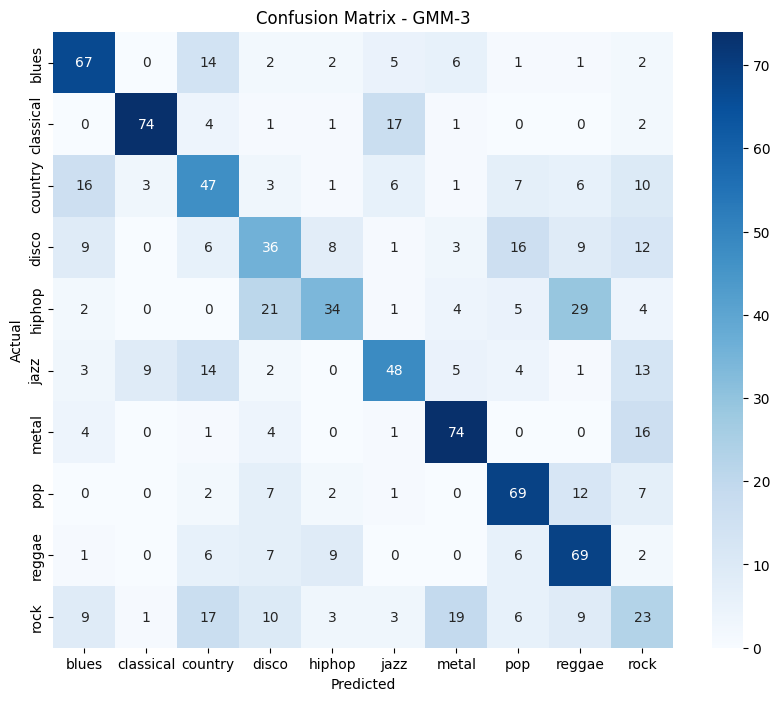

In [5]:
best_model_name = 'GMM-3'
actual, preds = all_preds[best_model_name]
cm = confusion_matrix(actual, preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y), cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()